# Day 1 — Manual filters

Apply simple kernels to images and treat the outputs as beginner-friendly feature maps.


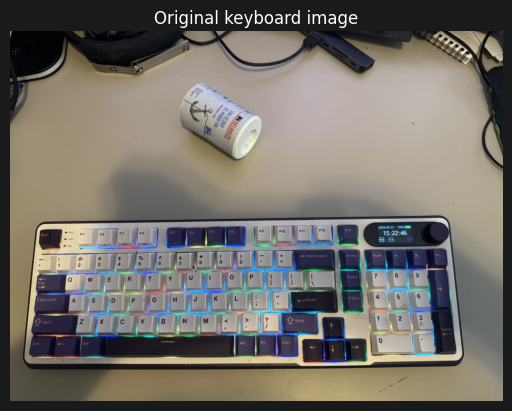

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

image_path = Path("../data/my_sample_image.jpg")
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.title("Original keyboard image")
plt.show()

In [3]:
import numpy as np

image_array = np.array(image)

image_array.shape, image_array.dtype, image_array.min(), image_array.max()

((4284, 5712, 3), dtype('uint8'), np.uint8(0), np.uint8(255))

## What the image shape means

The image array has shape `(4284, 5712, 3)`.

- `4284` = the image height: 4,284 rows of pixels.
- `5712` = the image width: 5,712 columns of pixels.
- `3` = the RGB color channels: red, green, and blue values for each pixel.
- `dtype("uint8")` means each color value is an unsigned 8-bit whole number, usually from `0` to `255`.
- `0` is the darkest channel value found in this image, and `255` is the brightest channel value found.

For this lab, the important idea is: filters do not see "keyboard" as a word or object. They scan pixel numbers and respond to local patterns like keycap edges, gaps, shadows, and outlines.


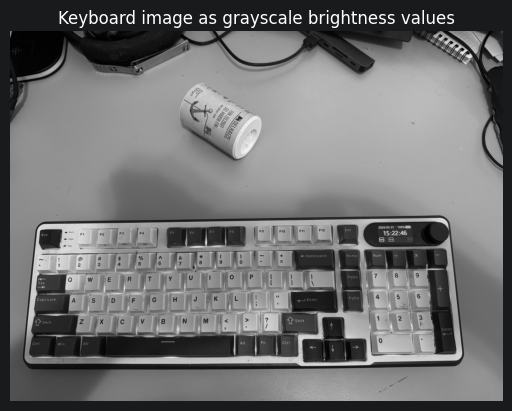

((4284, 5712), dtype('uint8'), np.uint8(0), np.uint8(255))

In [4]:
gray_image = image.convert("L")
gray_array = np.array(gray_image)

plt.imshow(gray_array, cmap="gray")
plt.axis("off")
plt.title("Keyboard image as grayscale brightness values")
plt.show()

gray_array.shape, gray_array.dtype, gray_array.min(), gray_array.max()

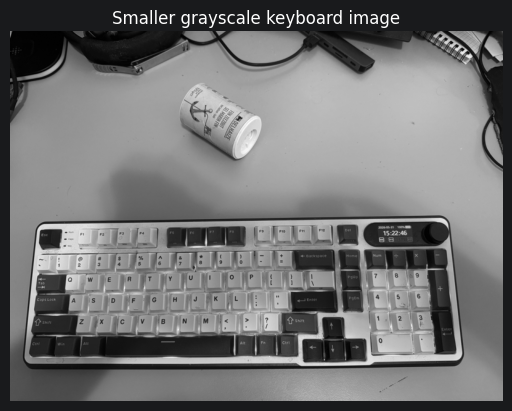

(600, 800)

In [5]:
max_width = 800
scale = max_width / gray_image.width
new_height = round(gray_image.height * scale)

small_gray_image = gray_image.resize((max_width, new_height))
small_gray_array = np.array(small_gray_image)

plt.imshow(small_gray_array, cmap="gray")
plt.axis("off")
plt.title("Smaller grayscale keyboard image")
plt.show()

small_gray_array.shape

## Manual left-right edge filter

This 3x3 kernel is a small grid of weights. A weight multiplies the matching pixel brightness in the current image patch.

- `-1` subtracts brightness from the left side of the patch.
- `0` ignores the middle column.
- `1` adds brightness from the right side of the patch.

The result is large when the left and right sides have very different brightness values, which often happens at vertical key edges and gaps.


In [6]:
import numpy as np

# Compare right-side brightness with left-side brightness in each 3x3 image patch.
# Positive values mean the right side is brighter; negative values mean the left side is brighter.
edge_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
])

## Apply the filter with `correlate2d`

`correlate2d` slides the kernel across the 2D grayscale image. At each location, it multiplies nearby pixel brightness values by the matching kernel weights and adds the results.

The output, `edge_response`, is another 2D grid. Strong positive or negative values mean the filter found a strong left-right brightness change at that location. Values near zero mean the nearby brightness values were similar.


## Tiny 2D example: how an edge map is built

A filter does not copy image patches into the output. It writes **one response number** for each patch position. Those response numbers form the new image, or feature map.

Input brightness grid with a vertical dark-to-bright change:

```text
10   10   10   200  200
10   10   10   200  200
10   10   10   200  200
10   10   10   200  200
10   10   10   200  200
```

Left-right edge kernel:

```text
-1   0   1
-1   0   1
-1   0   1
```

This kernel computes:

```text
sum(right column brightness) - sum(left column brightness)
```

A flat dark patch gives a near-zero response:

```text
10   10   10
10   10   10   ->   (10 + 10 + 10) - (10 + 10 + 10) = 0
10   10   10
```

A patch crossing the dark-to-bright edge gives a strong response:

```text
10   10   200
10   10   200   ->   (200 + 200 + 200) - (10 + 10 + 10) = 570
10   10   200
```

Ignoring borders for simplicity, the output feature map is the grid of those responses:

```text
0    570  570
0    570  570
0    570  570
```

Placed under the matching center positions, the responses line up with the edge region:

```text
input positions:           output responses:

10  10  10  200 200        .    .    .    .    .
10  10  10  200 200        .    0   570  570   .
10  10  10  200 200   ->   .    0   570  570   .
10  10  10  200 200        .    0   570  570   .
10  10  10  200 200        .    .    .    .    .
```

The `570` values are **filter responses**, not original brightness values. If displayed as an image, large response values appear bright, so the edge region becomes visible as a bright vertical band.


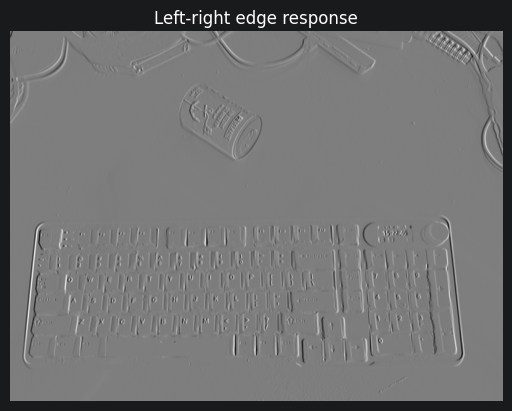

((600, 800), np.float64(-574.0), np.float64(587.0))

In [7]:
from scipy.signal import correlate2d

# Slide the edge kernel over the smaller grayscale image.
# mode="same" keeps the output the same height and width as the input image.
# boundary="symm" mirrors pixels at the border so edge pixels can still be processed.
edge_response = correlate2d(
    small_gray_array.astype(float),
    edge_kernel,
    mode="same",
    boundary="symm",
)

plt.imshow(edge_response, cmap="gray")
plt.axis("off")
plt.title("Left-right edge response")
plt.show()

edge_response.shape, edge_response.min(), edge_response.max()

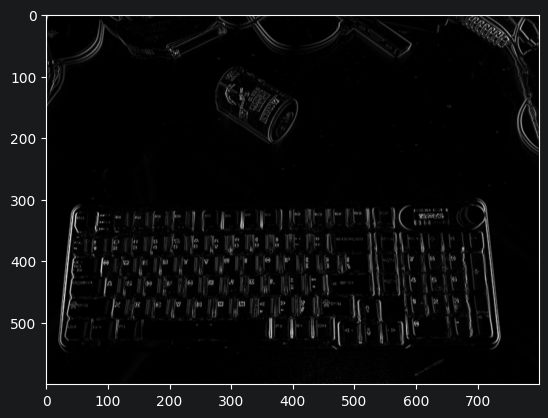

In [8]:
plt.imshow(np.abs(edge_response), cmap="gray")

## Read the edge map

The signed edge response keeps direction: positive means brightness increased left-to-right, and negative means brightness decreased left-to-right.

`np.abs(edge_response)` shows edge strength only. It keeps how strong the brightness change was, but it throws away which direction the brightness changed.
